                             Category  \
0                       Primary focus   
1     Market capitalisation (approx.)   
2  Latest cited share price (approx.)   
3              Trailing P/E (approx.)   
4                 Forward P/E (cited)   

                               Eli Lilly (NYSE: LLY)  \
0  Obesity, diabetes, immunology and innovative m...   
1                                      $1.02T-$1.08T   
2                                          $1,157.49   
3                                             38-39x   
4          Not consistently available in source data   

     Johnson & Johnson (NYSE: JNJ)  \
0  Innovative Medicine and MedTech   
1                      $612B-$668B   
2                          $254.78   
3                            29.5x   
4                     About 21-23x   

                                      Interpretation  
0  LLY is more concentrated; JNJ is more diversified  
1             Figures vary by provider and timestamp  
2      Share price alo

/var/folders/88/w4w1n8l12kd_z42_6mrnndmw0000gn/T/ipykernel_6044/1138764642.py:18: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text_cols = df.select_dtypes(include="object").columns


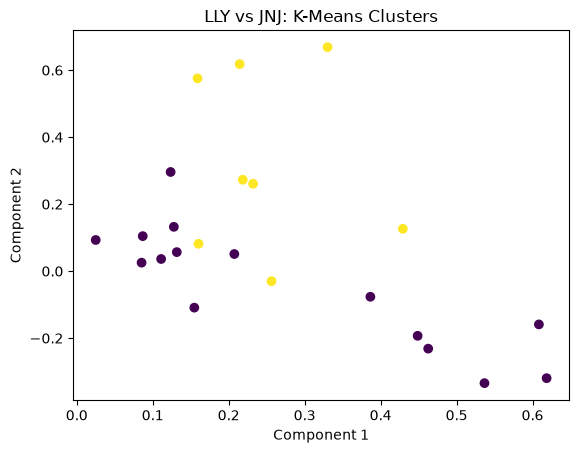

Cluster
0    15
1     8
dtype: int64
Analysis complete!


In [1]:
# LLY vs JNJ: K-Means and NLP Analysis

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import TruncatedSVD
from scipy.sparse import hstack, csr_matrix

# 1. Load dataset
df = pd.read_csv("LLY_vs_JNJ_comparison.csv")
df = df.dropna(how="all").copy()
print(df.head())

# 2. Identify text and numerical columns
text_cols = df.select_dtypes(include="object").columns
num_cols = df.select_dtypes(include=np.number).columns

# 3. NLP: convert text into TF-IDF features
text = df[text_cols].fillna("").astype(str).agg(" ".join, axis=1) \
    if len(text_cols) else pd.Series("", index=df.index)

tfidf = TfidfVectorizer(stop_words="english", max_features=500)
X_text = tfidf.fit_transform(text)

# 4. Scale numerical data
if len(num_cols):
    X_num = StandardScaler().fit_transform(
        df[num_cols].fillna(df[num_cols].median())
    )
    X = hstack([X_text, csr_matrix(X_num)]).tocsr()
else:
    X = X_text

# 5. K-Means clustering
k = min(2, len(df))
if len(df) < 2:
    raise ValueError("Dataset must contain at least 2 rows.")

model = KMeans(n_clusters=k, random_state=42, n_init=10)
df["Cluster"] = model.fit_predict(X)

# 6. Visualize clusters
if X.shape[1] >= 2:
    coords = TruncatedSVD(n_components=2, random_state=42).fit_transform(X)
    plt.scatter(coords[:, 0], coords[:, 1], c=df["Cluster"], cmap="viridis")
    plt.title("LLY vs JNJ: K-Means Clusters")
    plt.xlabel("Component 1")
    plt.ylabel("Component 2")
    plt.show()

# 7. Show and save results
print(df.groupby("Cluster").size())
df.to_csv("LLY_vs_JNJ_KMeans_NLP_Results.csv", index=False)
print("Analysis complete!")